# **Banco de Dados - Não Relacional**

**Instituição:** Pontifícia Universidade Católica de Campinas

**Curso:** Ciência de Dados e Inteligência Artificial

**Professor:** Felipe Cavalaro  

---

## Integrantes

| Nome | RA |
| :--- | :--- |
| Alice Pasolini | 25012938 |
| Enzo Guerra | 25007153 |
| Guilherme Cintra | 25004996 |
| Julia Leandro | 25009148 |
| Lavínia Oliveira | 25894981 |

### Instalação das Dependências

In [998]:
%pip install -r ../requirements.txt -q
# (Dependências devem estar pré-instaladas)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lalap\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [999]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import csv

# Grafos
import networkx as nx

Conexão com MongoDB

In [1000]:
import pymongo
from pymongo import MongoClient
import os
from pathlib import Path
from dotenv import load_dotenv

# Estratégia: sempre usar o caminho relativo ../
# Isso funciona tanto no Jupyter quanto quando importado como módulo

# Assumindo que o notebook está em Notebooks/
# Procuramos o .env em ../
env_path = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', '..', '.env'))

# Debug
print(f"[DEBUG] CWD: {os.getcwd()}")
print(f"[DEBUG] Procurando .env em: {env_path}")
print(f"[DEBUG] Arquivo existe? {os.path.exists(env_path)}")

load_dotenv(env_path)

# Verificar se carregou
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI carregado? {bool(MONGODB_URI)}")

[DEBUG] CWD: c:\Users\lalap\pi_educacao_qualidade\Notebooks
[DEBUG] Procurando .env em: c:\Users\lalap\pi_educacao_qualidade\.env
[DEBUG] Arquivo existe? True
[DEBUG] MONGODB_URI carregado? True


### Puxando os datasets

In [1001]:
REGIAO_CAMPINAS = ['CAMPINAS','HORTOLANDIA','SUMARE','INDAIATUBA','PAULINIA','AMERICANA','VALINHOS','SANTA BARBARA D\'OESTE']

In [1002]:
# Resolver caminho relativo ao arquivo do notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
CAMINHO_BASE = os.path.join(notebook_dir, "..", "Datasets Tratados")
CAMINHO_BASE = os.path.abspath(CAMINHO_BASE)

In [1003]:
def puxa_dataset(arquivo):
  url = os.path.join(CAMINHO_BASE, arquivo)
  return pd.read_csv(url, sep=',')

In [1004]:
sarespArq = "sarespDFTratado.csv"
sarespDF = puxa_dataset(sarespArq)

fluxoArq = "fluxoDFTratado.csv"
fluxoDF = puxa_dataset(fluxoArq)

ausArq = "ausDFTratado.csv"
ausDF = puxa_dataset(ausArq)

censoArq = "censoDFTratado.csv"
censoDF = puxa_dataset(censoArq)

In [1005]:
def inserir(arquivo, colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível inserir em '{colecao}'.")
    return
  collection = db[colecao]
  collection.delete_many({})
  with open(os.path.join(CAMINHO_BASE, arquivo), 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    collection.insert_many(reader)

In [1006]:
def visualizar(colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível visualizar '{colecao}'.")
    return
  
  lista_dfs = []
  for i in REGIAO_CAMPINAS:
      results = db[colecao].find({ "MUNICÍPIOS" : i})
      df = pd.DataFrame(list(results))

      if not df.empty:
          df = df.drop(columns=["_id"])
          lista_dfs.append(df)

  if lista_dfs:
      df = pd.concat(lista_dfs, ignore_index=True)
      print(df.to_string())
  else:
      print(f"Nenhum dado encontrado para a coleção '{colecao}'")

In [1007]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np
import zipfile

# Formatar encoding dos arquivos
import unicodedata

# Mongo

Conexão MongoDB

In [1008]:
# Carregando a URL de conexão MongoDB a partir do arquivo .env (por segurança)
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI definido? {bool(MONGODB_URI)}")
print(f"[DEBUG] URI começa com 'mongodb'? {str(MONGODB_URI or '').startswith('mongodb')}")

try:
    if not MONGODB_URI:
        raise ValueError("MONGODB_URI não foi definido no .env")
    
    client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=10000)
    print(f"[DEBUG] Testando conexão com MongoDB...")
    info = client.server_info()
    print(f"✓ Conectado ao MongoDB com sucesso!")
    print(f"  Versão: {info.get('version', 'desconhecida')}")
    db = client["datasets"]
except Exception as e:
    print(f"✗ Aviso: Não foi possível conectar ao MongoDB: {e}")
    client = None
    db = None

[DEBUG] MONGODB_URI definido? True
[DEBUG] URI começa com 'mongodb'? True
[DEBUG] Testando conexão com MongoDB...
✓ Conectado ao MongoDB com sucesso!
  Versão: 8.0.24


In [1009]:
arquivos = {
    sarespArq : "saresp",
    ausArq : "ausencia",
    fluxoArq : "fluxo",
    censoArq : "censo"
}

In [1010]:
for chave, valor in arquivos.items():
  inserir(chave, valor)

Verificação da função `inserir`

In [1011]:
print("Quantidade de documentos por dataset:\n")
if db is not None:
    for nome_colecao in ["saresp", "ausencia", "fluxo", "censo"]:
        qtd = db[nome_colecao].count_documents({})
        print(f"{nome_colecao}: {qtd} documentos")
else:
    print("MongoDB não está disponível. Não é possível contar documentos.")

Quantidade de documentos por dataset:

saresp: 134 documentos
ausencia: 24 documentos
fluxo: 24 documentos
censo: 78 documentos


Visualização do documento `json` como Dataframe

In [1012]:
for itens in arquivos.values():
  visualizar(itens)

                MUNICÍPIOS   ANO  SERIE_ANO        COMPETÊNCIA MÉDIA_PROFICIÊNCIA
0                 CAMPINAS  2022  2º Ano EF  LÍNGUA PORTUGUESA             178.67
1                 CAMPINAS  2022  2º Ano EF         MATEMÁTICA             186.57
2                 CAMPINAS  2022  5º Ano EF  LÍNGUA PORTUGUESA             195.97
3                 CAMPINAS  2022  5º Ano EF         MATEMÁTICA             210.67
4                 CAMPINAS  2022  9º Ano EF  LÍNGUA PORTUGUESA             237.18
5                 CAMPINAS  2022  9º Ano EF         MATEMÁTICA             242.05
6                 CAMPINAS  2023  2º Ano EF  LÍNGUA PORTUGUESA             171.73
7                 CAMPINAS  2023  2º Ano EF         MATEMÁTICA             163.45
8                 CAMPINAS  2023  5º Ano EF  LÍNGUA PORTUGUESA             194.07
9                 CAMPINAS  2023  5º Ano EF         MATEMÁTICA             205.82
10                CAMPINAS  2023  9º Ano EF  LÍNGUA PORTUGUESA             227.28
11              

In [1013]:
def visualizar_com_colunas(colecao, colunas=None):
  if db is None:
    print(f"Erro: MongoDB não está conectado.")
    return None
  
  lista_dfs = []
  for i in REGIAO_CAMPINAS:
      results = db[colecao].find({ "MUNICÍPIOS" : i})
      df = pd.DataFrame(list(results))

      if not df.empty:
          df = df.drop(columns=["_id"])
          lista_dfs.append(df)

  if lista_dfs:
      df = pd.concat(lista_dfs, ignore_index=True)
      
      # Se colunas específicas foram pedidas, retorna apenas essas
      if colunas:
          return df[colunas]
      return df
  else:
      print(f"Nenhum dado encontrado para '{colecao}'")
      return None

# Exemplos de uso:
df_ausencia = visualizar_com_colunas("ausencia")
print(df_ausencia.columns)  # Ver todas as colunas

# Acessar colunas específicas


Index(['MUNICÍPIOS', 'ANO', 'TOTAL FALTAS JUST', 'TOTAL FALTAS INJUST',
       'TOTAL DIAS AUSENTES'],
      dtype='str')


---

# Gráficos

### 01. Infraestrutura x Desempenho (SARESP) 

In [1014]:
#Pipeline que agrupa os dados do censo escolar e calcula a média de vários 
#indicadores de infraestrutura para cada município.
pipeline_censoInfra = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "biblioteca": {
                "$avg": {
                    "$convert": {
                        "input": "$BIBLIOTECA",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "sala_leitura": {
                "$avg": {
                    "$convert": {
                        "input": "$BIBLIOTECA OU SALA DE LEITURA",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "lab_info": {
                "$avg": {
                    "$convert": {
                        "input": "$LAB. INFORMÁTICA",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "lab_ciencias": {
                "$avg": {
                    "$convert": {
                        "input": "$LAB. CIÊNCIAS",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "internet": {
                "$avg": {
                    "$convert": {
                        "input": "$INTERNET",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "internet_alunos": {
                "$avg": {
                    "$convert": {
                        "input": "$INTERNET - ALUNOS",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            },

            "banda_larga": {
                "$avg": {
                    "$convert": {
                        "input": "$INTERNET - BANDA LARGA",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            }
        }
    }
]

#Executa o pipeline e armazena os resultados em uma lista
dados_censoInfra = list(db["censo"].aggregate(pipeline_censoInfra))


In [1015]:
#Lista vazia para armazenar os resultados de infraestrutura calculados
infraestrutura = []

#Percorre cada município vindo do MongoDB
#e calcula um índice médio de infraestrutura
for item in dados_censoInfra:
    indicadores = [
        item.get("biblioteca"),
        item.get("sala_leitura"),
        item.get("lab_info"),
        item.get("lab_ciencias"),
        item.get("internet"),
        item.get("internet_alunos"),
        item.get("banda_larga")
    ]

    indicadores_validos = [
        x for x in indicadores
        if x is not None
    ]

    indice = sum(indicadores_validos) / len(indicadores_validos)

    infraestrutura.append({
        "Município": item["_id"],
        "Infraestrutura": round(indice, 3)
    })

#Converte a lista de dicionários em DataFrame do pandas
df_censoInfra = pd.DataFrame(infraestrutura)
df_censoInfra

,Município,Infraestrutura
0,SUMARE,0.634
1,PAULINIA,0.653
2,VALINHOS,0.654
3,INDAIATUBA,0.689
4,SANTA BARBARA D'OESTE,0.639
5,AMERICANA,0.614
6,CAMPINAS,0.776
7,HORTOLANDIA,0.716


In [1016]:
#Pipeline que agrupa os dados do SARESP por município
#e calcula a média da proficiência convertendo os valores para número (double)
pipeline_sarespMedia = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",
            "saresp": {
                "$avg": {
                    "$convert": {
                        "input": "$MÉDIA_PROFICIÊNCIA",
                        "to": "double",
                        "onError": None,
                        "onNull": None
                    }
                }
            }
        }
    }
]

#Executa o pipeline no MongoDB e transforma o resultado em lista
dados_sarespMedia = list(db["saresp"].aggregate(pipeline_sarespMedia))

#Converte o resultado em um dicionário {chave: valor}:
#{município: valor médio do SARESP}
saresp_dict = {
    item["_id"]: item["saresp"]
    for item in dados_sarespMedia
}

#Converte a lista de dicionários em DataFrame do pandas
df_sarespMedia = pd.DataFrame(dados_sarespMedia)

#Renomeia colunas para facilitar leitura e padronizar nomes
df_sarespMedia.rename(
    columns={
        "_id": "Município",
        "saresp": "SARESP"
    },
    inplace=True
)

df_sarespMedia

,Município,SARESP
0,AMERICANA,215.102222
1,CAMPINAS,205.959444
2,PAULINIA,214.736429
3,VALINHOS,194.482778
4,SANTA BARBARA D'OESTE,218.882222
5,INDAIATUBA,227.276429
6,HORTOLANDIA,202.040625
7,SUMARE,198.146111


In [1017]:
#Lista que vai armazenar os dados finais combinados (infraestrutura + SARESP)
dados_finais = []

#Percorre cada município da lista de infraestrutura
#e verifica se ele também existe no dict do SARESP para combinar os dados
for item in infraestrutura:
    municipio = item["Município"]

    if municipio in saresp_dict:
        dados_finais.append({
            "Município": municipio,
            "Infraestrutura": item["Infraestrutura"],
            "SARESP": saresp_dict[municipio]
        })

#Converte a lista final em DataFrame para análise
df_analiseUm = pd.DataFrame(dados_finais)
df_analiseUm

,Município,Infraestrutura,SARESP
0,SUMARE,0.634,198.146111
1,PAULINIA,0.653,214.736429
2,VALINHOS,0.654,194.482778
3,INDAIATUBA,0.689,227.276429
4,SANTA BARBARA D'OESTE,0.639,218.882222
5,AMERICANA,0.614,215.102222
6,CAMPINAS,0.776,205.959444
7,HORTOLANDIA,0.716,202.040625


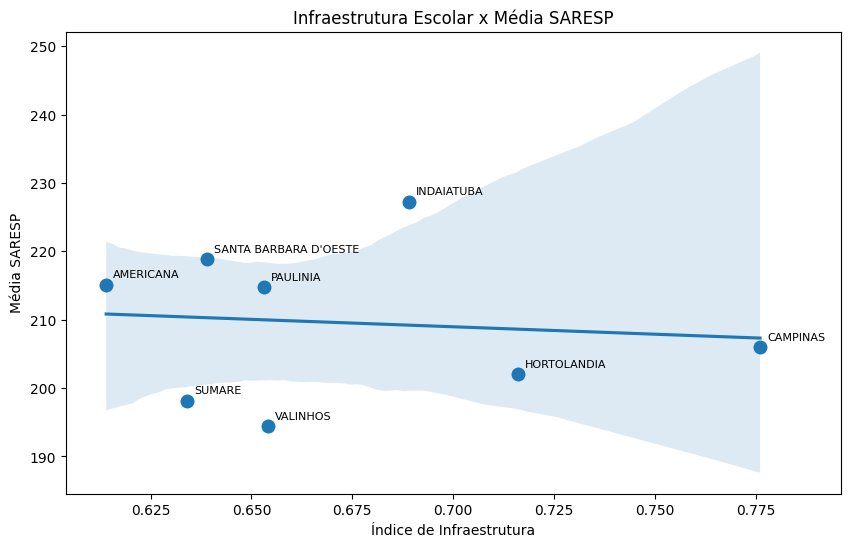

In [1018]:
plt.figure(figsize=(10,6))

#Plota um gráfico de dispersão entre infraestrutura e SARESP
sns.scatterplot(
    data = df_analiseUm,
    x = "Infraestrutura",
    y = "SARESP",
    s = 120
)

#Adiciona uma linha de tendência (regressão linear) sem repetir os pontos
sns.regplot(
    data = df_analiseUm,
    x = "Infraestrutura",
    y = "SARESP",
    scatter = False,   #Não desenha os pontos de novo        
)

#Adiciona o nome de cada município em cada ponto do gráfico
for _, row in df_analiseUm.iterrows():
    plt.annotate(
        row["Município"],
        (row["Infraestrutura"], row["SARESP"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

xmin = df_analiseUm["Infraestrutura"].min()
xmax = df_analiseUm["Infraestrutura"].max()

plt.xlim(xmin - 0.01, xmax + 0.02)
plt.title("Infraestrutura Escolar x Média SARESP")
plt.xlabel("Índice de Infraestrutura")
plt.ylabel("Média SARESP")

plt.show()

### 02. Ausência de Docentes x Reprovação e Aprovação

In [1019]:
#Pipeline que agrupa os dados de ausência por município
#e calcula a média de dias ausentes convertendo os valores double
pipeline_ausenciaMedia = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",
            "dias_ausentes": {
                "$avg": {
                    "$toDouble": "$TOTAL DIAS AUSENTES"
                }
            }
        }
    }
]

#Executa o pipeline no MongoDB e transforma o resultado em lista
dados_ausenciaMedia = list(db["ausencia"].aggregate(pipeline_ausenciaMedia))

#Converte o resultado em DataFrame para análise no pandas
df_ausenciaMedia = pd.DataFrame(dados_ausenciaMedia)

df_ausenciaMedia = df_ausenciaMedia.rename(columns={"_id": "Município"})


In [1020]:
#Pipeline que agrupa os dados de fluxo escolar por município
#e calcula médias de aprovação e reprovação (anos iniciais e finais)
pipeline_fluxoMedia = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "aprovacao": {
                "$avg": {
                    "$divide": [
                        {
                            "$add": [
                                {"$toDouble": "$APROVAÇÃO ANOS INICIAIS 9 ANOS"},
                                {"$toDouble": "$APROVAÇÃO ANOS FINAIS 9 ANOS"}
                            ]
                        },
                        2
                    ]
                }
            },

            "reprovacao": {
                "$avg": {
                    "$divide": [
                        {
                            "$add": [
                                {"$toDouble": "$REPROVAÇÃO ANOS INICIAIS 9 ANOS"},
                                {"$toDouble": "$REPROVAÇÃO ANOS FINAIS 9 ANOS"}
                            ]
                        },
                        2
                    ]
                }
            }
        }
    }
]

#Executa o pipeline no MongoDB e converte o resultado em lista
dados_fluxoMedia = list(db["fluxo"].aggregate(pipeline_fluxoMedia))

#Dicionário que vai armazenar os dados de fluxo escolar por município
fluxoMedia_dict = {}

#Percorre cada registro, utilizando o município como chave do dicionário
#e armazena um subdicionário com aprovação e reprovação
for item in dados_fluxoMedia:
    fluxoMedia_dict[item["_id"]] = {
        "aprovacao": item["aprovacao"],
        "reprovacao": item["reprovacao"]
    }

In [1021]:
#Lista que vai armazenar os dados finais combinando ausência e fluxo escolar
dados_finais = [] 

#Percorre cada município de ausência
#e combina seus dados com aprovação e reprovação quando existir no fluxo escolar
for item in dados_ausenciaMedia: 
    municipio = item["_id"] 
    
    if municipio in fluxoMedia_dict: 
        dados_finais.append({ 
            "Município": municipio, 
            "Dias_Ausentes": item["dias_ausentes"], 
            "Aprovação": fluxoMedia_dict[municipio]["aprovacao"], 
            "Reprovação": fluxoMedia_dict[municipio]["reprovacao"] 
        })

#Converte a lista de dicionários em DataFrame do pandas para análise
df_analiseDois = pd.DataFrame(dados_finais)
df_analiseDois

,Município,Dias_Ausentes,Aprovação,Reprovação
0,SUMARE,2272.333333,98.703333,1.198333
1,PAULINIA,319.333333,48.348333,1.611667
2,VALINHOS,414.333333,48.865000,1.033333
3,INDAIATUBA,2144.666667,49.301667,0.531667
4,SANTA BARBARA D'OESTE,935.666667,99.301667,0.571667
5,AMERICANA,1140.000000,98.651667,1.226667
6,CAMPINAS,9976.666667,98.268333,1.516667
7,HORTOLANDIA,1557.000000,99.198333,0.681667


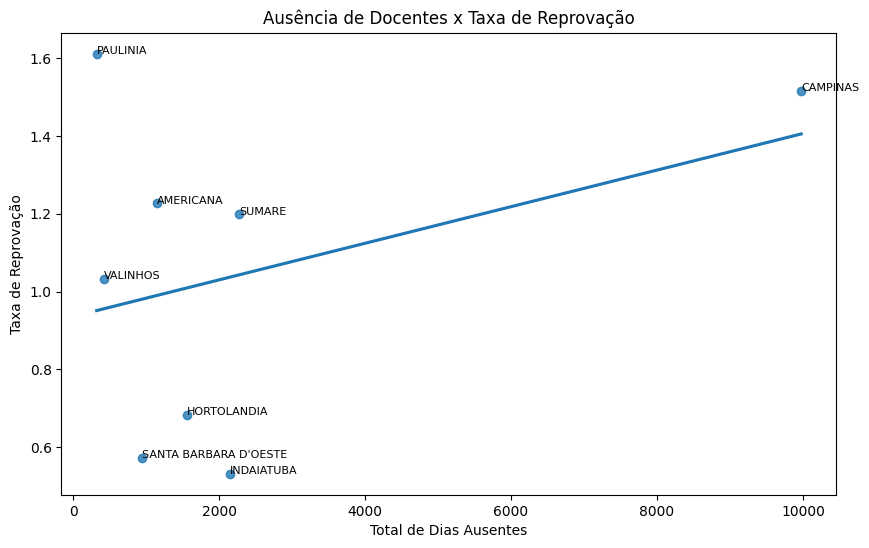

In [1022]:
plt.figure(figsize=(10,6))

#Plota a relação entre dias ausentes e taxa de reprovação,
#com uma linha de tendência (regressão linear)
sns.regplot(
    data=df_analiseDois,
    x="Dias_Ausentes",
    y="Reprovação",
    ci=None
)

#Percorre cada linha do DataFrame para adicionar o nome do município no gráfico
for _, row in df_analiseDois.iterrows():
    plt.annotate(
        row["Município"],
        (row["Dias_Ausentes"], row["Reprovação"]),
        fontsize=8
    )

plt.title("Ausência de Docentes x Taxa de Reprovação")
plt.xlabel("Total de Dias Ausentes")
plt.ylabel("Taxa de Reprovação")

plt.show()

### 03. Tecnologia x Desempenho (SARESP)

In [1023]:
#Pipeline que agrupa os dados do censo escolar e calcula a média de vários 
#indicadores de infraestrutura relacionados a tecnologia para cada município.
pipeline_tecnologiaInfra = [
    {
        "$project": {

            "MUNICÍPIOS": 1,

            "computadores": {
                "$convert": {
                    "input": "$Quantidade de computadores em uso pelos alunos",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "lousa": {
                "$convert": {
                    "input": "$QTDE LOUSAS DIGITAIS",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "datashow": {
                "$convert": {
                    "input": "$QTDE DATASHOW",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "internet_alunos": {
                "$convert": {
                    "input": "$INTERNET - ALUNOS",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            }
        }
    },

    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "computadores": {"$avg": "$computadores"},
            "lousa": {"$avg": "$lousa"},
            "datashow": {"$avg": "$datashow"},
            "internet_alunos": {"$avg": "$internet_alunos"}
        }
    }
]

#Executa o pipeline na coleção censo e transforma o resultado em DataFrame
dados_tecInfra = list(db["censo"].aggregate(pipeline_tecnologiaInfra))
df_tecInfra = pd.DataFrame(dados_tecInfra)

In [1024]:
#Cria o normalizador Min-Max para colocar os valores na mesma escala (0 a 1)
scaler = MinMaxScaler()

#Colunas de infraestrutura tecnológica que serão normalizadas
cols = [
    "computadores",
    "lousa",
    "datashow",
    "internet_alunos"
]

#Aplica a normalização nas colunas selecionadas,
#garantindo que todas fiquem na mesma escala para comparação
df_tecInfra[cols] = scaler.fit_transform(df_tecInfra[cols])

In [1025]:
#Cria um índice único de tecnologia educacional por município
#calculando a média dos indicadores já normalizados
df_tecInfra["Indice_Tecnologia"] = (
    df_tecInfra["computadores"] +
    df_tecInfra["lousa"] +
    df_tecInfra["datashow"] +
    df_tecInfra["internet_alunos"]
) / 4

df_tecInfra = df_tecInfra.rename(columns={"_id": "Município"})

In [1026]:
print(df_tecInfra.columns)

Index(['Município', 'computadores', 'lousa', 'datashow', 'internet_alunos',
       'Indice_Tecnologia'],
      dtype='str')


In [1027]:
#Junta os dados de tecnologia educacional com os dados de SARESP
#usando o município como primary key
df_analiseTres = pd.merge(
    df_tecInfra[["Município", "Indice_Tecnologia"]],
    df_sarespMedia,
    on="Município"
)

df_analiseTres

,Município,Indice_Tecnologia,SARESP
0,SUMARE,0.346093,198.146111
1,PAULINIA,0.000132,214.736429
2,VALINHOS,0.233029,194.482778
3,INDAIATUBA,0.245800,227.276429
4,SANTA BARBARA D'OESTE,0.220479,218.882222
5,AMERICANA,0.109608,215.102222
6,CAMPINAS,0.750000,205.959444
7,HORTOLANDIA,0.292445,202.040625


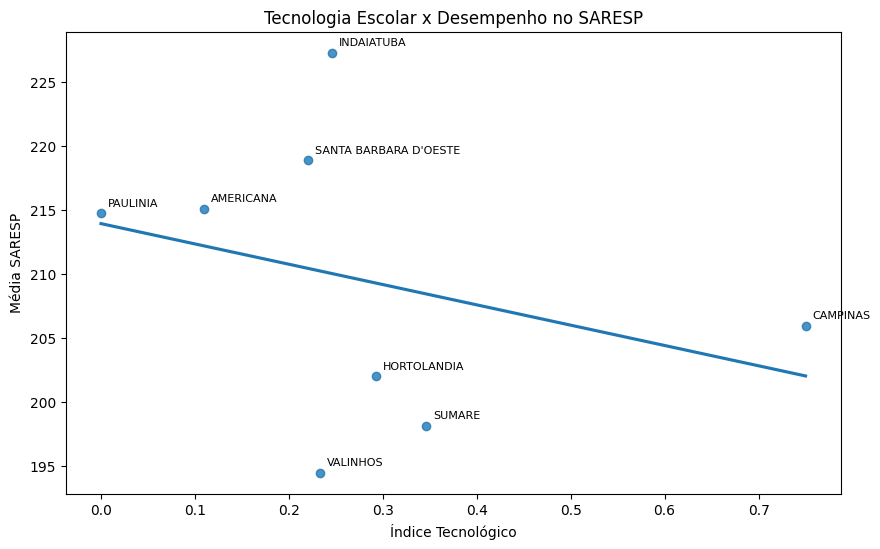

In [1028]:
plt.figure(figsize=(10,6))

#Plota a relação entre índice de tecnologia educacional e desempenho no SARESP,
#incluindo a linha de regressão para observar tendência de correlação
sns.regplot(
    data=df_analiseTres,
    x="Indice_Tecnologia",
    y="SARESP",
    ci=None
)

#Adiciona rótulos com o nome de cada município em cada ponto do gráfico
for _, row in df_analiseTres.iterrows():
    plt.annotate(
        row["Município"],
        (row["Indice_Tecnologia"], row["SARESP"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Tecnologia Escolar x Desempenho no SARESP")
plt.xlabel("Índice Tecnológico")
plt.ylabel("Média SARESP")

plt.show()

### 04. Relação Professor-Aluno

In [1029]:
#Pipeline que agrupa os dados do censo por município
#e calcula a média de docentes e matrículas do ensino fundamental
pipeline_censoDocentes = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "docentes": {
                "$avg": {
                    "$toDouble":
                    "$QTDE DOCENTES FUNDAMENTAL - TOTAL"
                }
            },

            "matriculas": {
                "$avg": {
                    "$toDouble":
                    "$QTDE MATRICULAS FUNDAMENTAL - TOTAL"
                }
            }
        }
    }
]

#Executa o pipeline no MongoDB e transforma o resultado em lista
dados_censoDocentes = list(db["censo"].aggregate(pipeline_censoDocentes))

In [1030]:
#Lista vazia para armazenar os dados de relação aluno/professor por município
dados_professor = []

#Percorre cada município de docentes e matrículas
#e calcula a relação aluno/professor apenas quando há docentes>0
for item in dados_censoDocentes:
    if item["docentes"] > 0:
        alunos_professor = (item["matriculas"] / item["docentes"])

        dados_professor.append({
            "Município": item["_id"],
            "Aluno_Professor": alunos_professor
        })

#Converte a lista de dicionários em DataFrame do pandas
df_qtdProf = pd.DataFrame(dados_professor)

In [ ]:
#Pipeline que calcula a média de dias de ausência de docentes por município
#e agrega esses dados no MongoDB convertendo os valores para número
pipeline_fluxo = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "aprovacao": {
                "$avg": {
                    "$divide": [
                        {
                            "$add": [
                                {
                                    "$toDouble":
                                    "$APROVAÇÃO ANOS INICIAIS 9 ANOS"
                                },
                                {
                                    "$toDouble":
                                    "$APROVAÇÃO ANOS FINAIS 9 ANOS"
                                }
                            ]
                        },
                        2
                    ]
                }
            }
        }
    }
]

#Executa o pipeline no MongoDB e transforma o resultado em lista
dados_fluxo = list(db["fluxo"].aggregate(pipeline_fluxo))

In [1060]:
#Converte a lista de dicionários em DataFrame do pandas
df_fluxo = pd.DataFrame(dados_fluxo)

#Padroniza os nomes das colunas para facilitar a leitura e análise
df_fluxo.rename(
    columns={
        "_id": "Município",
        "aprovacao": "Aprovação"
    },
    inplace=True
)

#Junta os dados de relação aluno/professor com os dados de aprovação do fluxo escolar
df_analiseQuatro = pd.merge(
    df_qtdProf,
    df_fluxo,
    on="Município"
)

df_analiseQuatro

,Município,Aluno_Professor,Aprovação
0,AMERICANA,15.955258,98.651667
1,CAMPINAS,16.121614,98.268333
2,HORTOLANDIA,18.373732,99.198333
3,SUMARE,17.606294,98.703333
4,INDAIATUBA,16.798072,49.301667
5,SANTA BARBARA D'OESTE,14.585360,99.301667
6,PAULINIA,18.751064,48.348333
7,VALINHOS,14.691828,48.865000


In [ ]:
#Cria o normalizador Min-Max para colocar os valores de aluno/professor e aprovação na mesma escala (0 a 1)
scaler = MinMaxScaler()

#Faz uma cópia do DataFrame para plotagem, preservando os dados originais
df_plot = df_analiseQuatro.copy()

#Aplica a normalização Min-Max nas colunas de relação aluno/professor e aprovação,
df_plot[["Aluno_Professor", "Aprovação"]] = scaler.fit_transform(df_plot[["Aluno_Professor", "Aprovação"]])

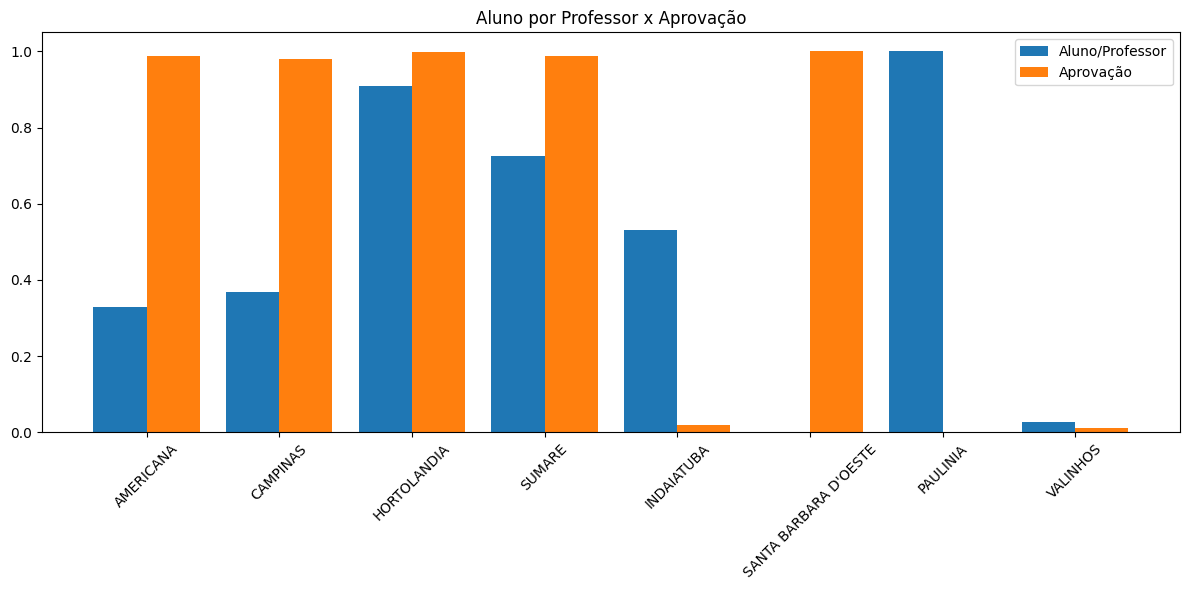

In [1034]:
x = np.arange(len(df_plot))

plt.figure(figsize=(12,6))

plt.bar(
    x - 0.2,
    df_plot["Aluno_Professor"],
    width=0.4,
    label="Aluno/Professor"
)

plt.bar(
    x + 0.2,
    df_plot["Aprovação"],
    width=0.4,
    label="Aprovação"
)

plt.xticks(
    x,
    df_plot["Município"],
    rotation=45
)

plt.title("Aluno por Professor x Aprovação")

plt.legend()
plt.tight_layout()
plt.show()


### 05. Evolução temporal

In [1035]:
pipeline_sarespAno = [
    {
        "$group": {
            "_id": "$ANO",
            "saresp": {
                "$avg": {
                    "$toDouble": "$MÉDIA_PROFICIÊNCIA"
                }
            }
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

dados_sarespAno = list(db["saresp"].aggregate(pipeline_sarespAno))
df_sarespAno = pd.DataFrame(dados_sarespAno)

In [1036]:
pipeline_fluxoAno = [
    {
        "$group": {
            "_id": "$ANO",

            "aprovacao": {
                "$avg": {
                    "$divide": [
                        {
                            "$add": [
                                {
                                    "$toDouble":
                                    "$APROVAÇÃO ANOS INICIAIS 9 ANOS"
                                },
                                {
                                    "$toDouble":
                                    "$APROVAÇÃO ANOS FINAIS 9 ANOS"
                                }
                            ]
                        },
                        2
                    ]
                }
            }
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

dados_fluxoAno = list(db["fluxo"].aggregate(pipeline_fluxoAno))
df_fluxoAno = pd.DataFrame(dados_fluxoAno)

In [1037]:
pipeline_ausenciaAno = [
    {
        "$group": {
            "_id": "$ANO",

            "ausencia": {
                "$avg": {
                    "$toDouble":
                    "$TOTAL DIAS AUSENTES"
                }
            }
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

dados_ausenciaAno = list(db["ausencia"].aggregate(pipeline_ausenciaAno))
df_ausenciaAno = pd.DataFrame(dados_ausenciaAno)

In [1038]:
pipeline_infraAno = [
    {
        "$project": {

            "ANO": 1,

            "biblioteca": {
                "$convert": {
                    "input": "$BIBLIOTECA",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "sala_leitura": {
                "$convert": {
                    "input": "$BIBLIOTECA OU SALA DE LEITURA",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "lab_info": {
                "$convert": {
                    "input": "$LAB. INFORMÁTICA",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "lab_ciencias": {
                "$convert": {
                    "input": "$LAB. CIÊNCIAS",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "internet": {
                "$convert": {
                    "input": "$INTERNET",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "internet_alunos": {
                "$convert": {
                    "input": "$INTERNET - ALUNOS",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            },

            "banda_larga": {
                "$convert": {
                    "input": "$INTERNET - BANDA LARGA",
                    "to": "double",
                    "onError": None,
                    "onNull": None
                }
            }
        }
    },

    {
        "$group": {
            "_id": "$ANO",

            "biblioteca": {"$avg": "$biblioteca"},
            "sala_leitura": {"$avg": "$sala_leitura"},
            "lab_info": {"$avg": "$lab_info"},
            "lab_ciencias": {"$avg": "$lab_ciencias"},
            "internet": {"$avg": "$internet"},
            "internet_alunos": {"$avg": "$internet_alunos"},
            "banda_larga": {"$avg": "$banda_larga"}
        }
    },

    {
        "$sort": {
            "_id": 1
        }
    }
]

dados_infraAno = list(db["censo"].aggregate(pipeline_infraAno))

In [1039]:
infra = []

for item in dados_infraAno:

    indicadores = [
        item["biblioteca"],
        item["sala_leitura"],
        item["lab_info"],
        item["lab_ciencias"],
        item["internet"],
        item["internet_alunos"],
        item["banda_larga"]
    ]

    indicadores = [
        x for x in indicadores
        if x is not None
    ]

    indice = sum(indicadores) / len(indicadores)

    infra.append({
        "ANO": item["_id"],
        "INFRAESTRUTURA": indice
    })

df_infraAno = pd.DataFrame(infra)

In [1040]:
df_merge1 = (
    df_sarespAno
    .merge(df_fluxoAno, on="_id")
    .merge(df_ausenciaAno, on="_id")
)

df_merge1.rename(
    columns={"_id": "ANO"},
    inplace=True
)

df_merge2 = df_merge1.merge(
    df_infraAno,
    on="ANO"
)

print(df_merge2)


    ANO      saresp  aprovacao  ausencia  INFRAESTRUTURA
0  2022  215.494474  79.850625  3125.625        0.670846
1  2023  196.037292  80.041250  2379.000        0.679000
2  2024  216.845000  80.347500  1530.375        0.682462


In [1041]:
df_merge2 = df_merge2.rename(columns={
    "saresp": "SARESP",
    "aprovacao": "APROVACAO",
    "ausencia": "AUSENCIA"
})

In [1042]:
df_merge2.columns

Index(['ANO', 'SARESP', 'APROVACAO', 'AUSENCIA', 'INFRAESTRUTURA'], dtype='str')

In [1043]:
scaler = MinMaxScaler()

colunas = [
    "SARESP",
    "APROVACAO",
    "AUSENCIA",
    "INFRAESTRUTURA"
]

df_analiseCinco = df_merge2.copy()

df_analiseCinco[colunas] = scaler.fit_transform(df_analiseCinco[colunas])

In [1044]:
print([x["_id"] for x in dados_sarespAno])
print([x["_id"] for x in dados_fluxoAno])
print([x["_id"] for x in dados_ausenciaAno])
print([x["_id"] for x in dados_infraAno])

['2022', '2023', '2024']
['2022', '2023', '2024']
['2022', '2023', '2024']
['2022', '2023', '2024']


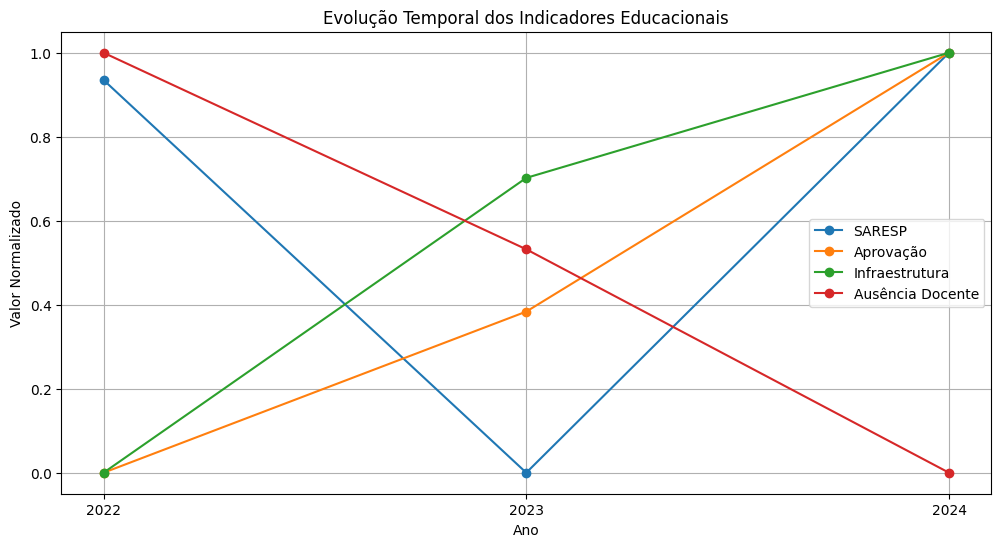

In [1045]:
plt.figure(figsize=(12,6))

plt.plot(
    df_analiseCinco["ANO"],
    df_analiseCinco["SARESP"],
    marker="o",
    label="SARESP"
)

plt.plot(
    df_analiseCinco["ANO"],
    df_analiseCinco["APROVACAO"],
    marker="o",
    label="Aprovação"
)

plt.plot(
    df_analiseCinco["ANO"],
    df_analiseCinco["INFRAESTRUTURA"],
    marker="o",
    label="Infraestrutura"
)

plt.plot(
    df_analiseCinco["ANO"],
    df_analiseCinco["AUSENCIA"],
    marker="o",
    label="Ausência Docente"
)

plt.title("Evolução Temporal dos Indicadores Educacionais")
plt.xlabel("Ano")
plt.ylabel("Valor Normalizado")

plt.grid(True)
plt.legend()

plt.show()

### 06. Ranking de municípios

In [1046]:
pipeline_fluxoMedia = [
    {
        "$group": {
            "_id": "$MUNICÍPIOS",

            "aprovacao": {
                "$avg": {
                    "$divide": [
                        {
                            "$add": [
                                {
                                    "$convert": {
                                        "input": "$APROVAÇÃO ANOS INICIAIS 9 ANOS",
                                        "to": "double",
                                        "onError": None,
                                        "onNull": None
                                    }
                                },
                                {
                                    "$convert": {
                                        "input": "$APROVAÇÃO ANOS FINAIS 9 ANOS",
                                        "to": "double",
                                        "onError": None,
                                        "onNull": None
                                    }
                                }
                            ]
                        },
                        2
                    ]
                }
            }
        }
    }
]

df_fluxoMedia = pd.DataFrame(list(db["fluxo"].aggregate(pipeline_fluxoMedia)))

df_fluxoMedia.rename(
    columns={
        "_id": "Município",
        "aprovacao": "Aprovação"
    },
    inplace=True
)

In [1047]:
df_ausenciaMedia

,Município,dias_ausentes
0,SUMARE,2272.333333
1,PAULINIA,319.333333
2,VALINHOS,414.333333
3,INDAIATUBA,2144.666667
4,SANTA BARBARA D'OESTE,935.666667
5,AMERICANA,1140.000000
6,CAMPINAS,9976.666667
7,HORTOLANDIA,1557.000000


In [1048]:
df_ranking = (
    df_sarespMedia
    .merge(
        df_fluxoMedia,
        on="Município"
    )
    .merge(
        df_censoInfra,
        on="Município"
    )
    .merge(
        df_ausenciaMedia,
        on="Município"
    )
)

In [1049]:
#Padroniza nomes das colunas no ranking
df_ranking = df_ranking.rename(columns={
    "Município": "MUNICIPIO",
    "SARESP": "SARESP",
    "Aprovação": "APROVACAO",
    "Infraestrutura": "INFRAESTRUTURA",
    "dias_ausentes": "AUSENCIA"
})

In [1050]:
df_ranking

,MUNICIPIO,SARESP,APROVACAO,INFRAESTRUTURA,AUSENCIA
0,AMERICANA,215.102222,98.651667,0.614,1140.000000
1,CAMPINAS,205.959444,98.268333,0.776,9976.666667
2,PAULINIA,214.736429,48.348333,0.653,319.333333
3,VALINHOS,194.482778,48.865000,0.654,414.333333
4,SANTA BARBARA D'OESTE,218.882222,99.301667,0.639,935.666667
5,INDAIATUBA,227.276429,49.301667,0.689,2144.666667
6,HORTOLANDIA,202.040625,99.198333,0.716,1557.000000
7,SUMARE,198.146111,98.703333,0.634,2272.333333


In [1051]:
scaler = MinMaxScaler()

colunas = [
    "SARESP",
    "APROVACAO",
    "INFRAESTRUTURA",
    "AUSENCIA"
]

df_norm = df_ranking.copy()

df_norm[colunas] = scaler.fit_transform(
    df_norm[colunas]
)

In [1052]:
df_norm["AUSENCIA"] = (
    1 - df_norm["AUSENCIA"]
)

df_norm["Índice Educação"] = (

    0.40 * df_norm["SARESP"]

    + 0.30 * df_norm["APROVACAO"]

    + 0.20 * df_norm["INFRAESTRUTURA"]

    + 0.10 * df_norm["AUSENCIA"]

)

df_analiseSeis = df_norm.sort_values(
    by="Índice Educação",
    ascending=False
)

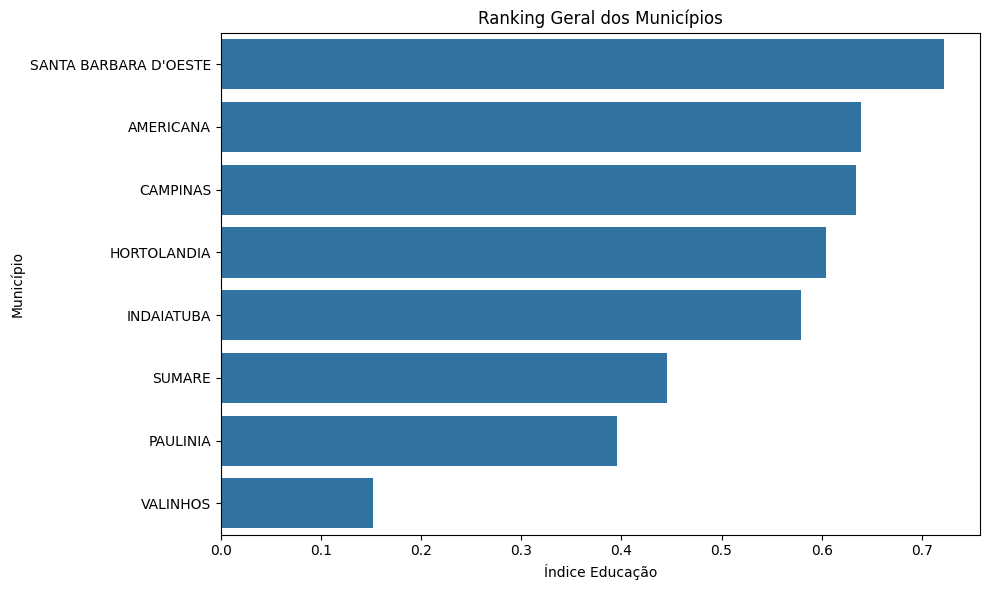

In [1053]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data = df_analiseSeis,
    y = "MUNICIPIO",
    x = "Índice Educação"
)

plt.title(
    "Ranking Geral dos Municípios"
)

plt.xlabel(
    "Índice Educação"
)

plt.ylabel(
    "Município"
)

plt.tight_layout()

plt.show()

---

# Grafos

In [1054]:
visualizar_com_colunas("ausencia", ["MUNICÍPIOS", "ANO", "TOTAL DIAS AUSENTES"])

,MUNICÍPIOS,ANO,TOTAL DIAS AUSENTES
0,CAMPINAS,2022,12805
1,CAMPINAS,2023,10152
2,CAMPINAS,2024,6973
3,HORTOLANDIA,2022,1670
4,HORTOLANDIA,2023,1914
5,HORTOLANDIA,2024,1087
6,SUMARE,2022,2962
7,SUMARE,2023,2479
8,SUMARE,2024,1376
9,INDAIATUBA,2022,3264


In [1055]:
docentes_total = visualizar_com_colunas("censo", ["MUNICÍPIOS", "ANO", "QTDE DOCENTES FUNDAMENTAL - TOTAL"])
docentes_total["QTDE DOCENTES FUNDAMENTAL - TOTAL"] = pd.to_numeric(docentes_total["QTDE DOCENTES FUNDAMENTAL - TOTAL"], errors='coerce')
docentes_agrupados = docentes_total.groupby("MUNICÍPIOS")["QTDE DOCENTES FUNDAMENTAL - TOTAL"].sum()
docentes_agrupados

MUNICÍPIOS
AMERICANA                 4850.0
CAMPINAS                 23739.0
HORTOLANDIA               5223.0
INDAIATUBA                5809.0
PAULINIA                  2350.0
SANTA BARBARA D'OESTE     4153.0
SUMARE                    5593.0
VALINHOS                  3047.0
Name: QTDE DOCENTES FUNDAMENTAL - TOTAL, dtype: float64

In [1056]:
ausencia_total=visualizar_com_colunas("ausencia", ["MUNICÍPIOS", "ANO", "TOTAL DIAS AUSENTES"])
ausencia_total["TOTAL DIAS AUSENTES"] = pd.to_numeric(ausencia_total["TOTAL DIAS AUSENTES"], errors='coerce')
ausencia_agrupada=ausencia_total.groupby("MUNICÍPIOS")["TOTAL DIAS AUSENTES"].sum()

In [1057]:
dfnovo=pd.DataFrame()
dfnovo["taxa_ausencia"] = ausencia_agrupada / docentes_agrupados
dfnovo.head(100)

,taxa_ausencia
MUNICÍPIOS,
AMERICANA,0.705155
CAMPINAS,1.260794
HORTOLANDIA,0.894314
INDAIATUBA,1.107592
PAULINIA,0.407660
SANTA BARBARA D'OESTE,0.675897
SUMARE,1.218845
VALINHOS,0.407942


In [1058]:
saresptotal=visualizar_com_colunas("saresp", ["MUNICÍPIOS", "ANO","MÉDIA_PROFICIÊNCIA"])
saresptotal["MÉDIA_PROFICIÊNCIA"] = pd.to_numeric(saresptotal["MÉDIA_PROFICIÊNCIA"], errors='coerce')
saresp_agrupado = saresptotal.groupby("MUNICÍPIOS")["MÉDIA_PROFICIÊNCIA"].mean()
saresp_agrupado.head(100)

MUNICÍPIOS
AMERICANA                215.102222
CAMPINAS                 205.959444
HORTOLANDIA              202.040625
INDAIATUBA               227.276429
PAULINIA                 214.736429
SANTA BARBARA D'OESTE    218.882222
SUMARE                   198.146111
VALINHOS                 194.482778
Name: MÉDIA_PROFICIÊNCIA, dtype: float64

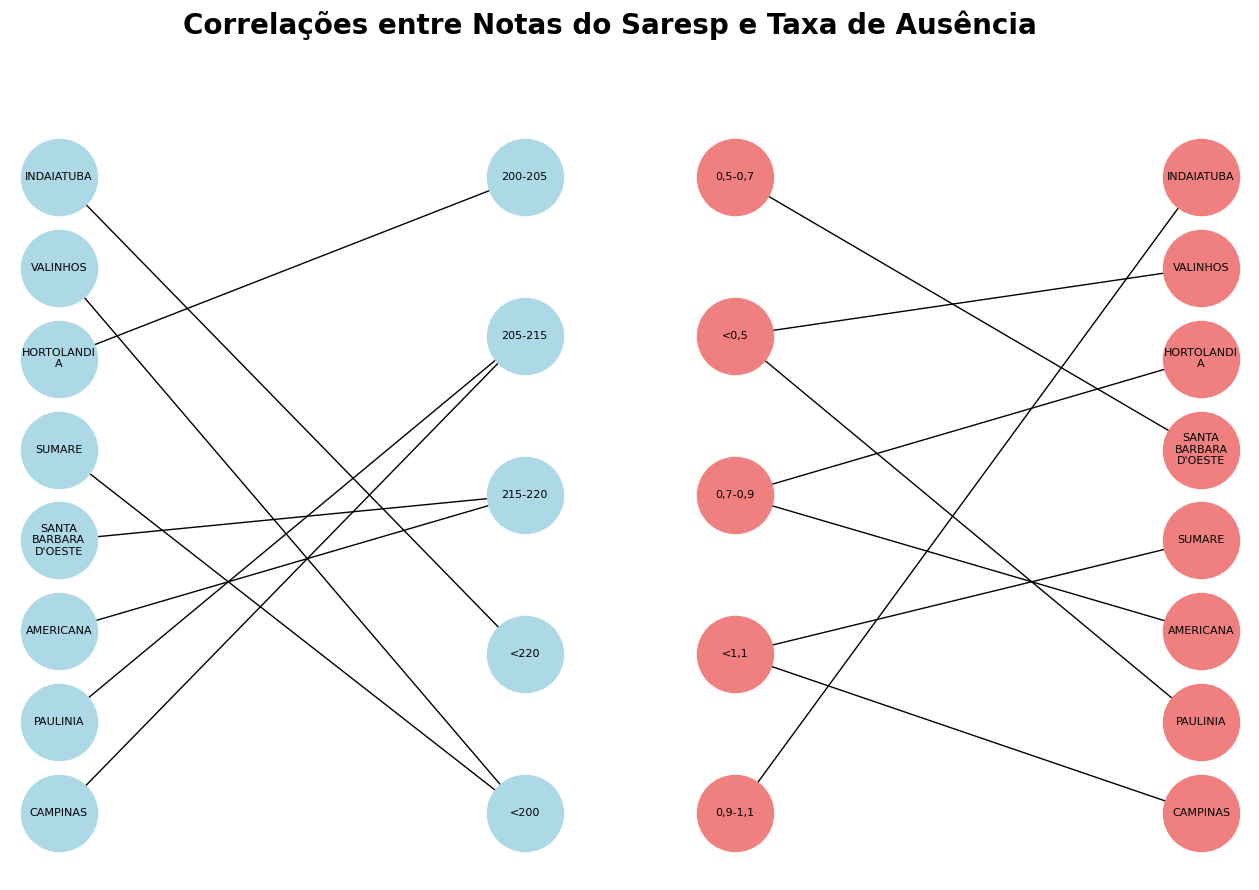

In [1059]:
import textwrap

G=nx.Graph()
H=nx.Graph()
H.add_nodes_from(["<0,5","0,5-0,7","0,7-0,9","0,9-1,1","<1,1"])
H.add_nodes_from(docentes_agrupados.index)
G.add_nodes_from(docentes_agrupados.index)
G.add_nodes_from(["<200","200-205","205-215","215-220","<220"])
edge_labels1 = [
    "215-220",
    "205-215",
    "200-205",
    "<220",
    "205-215",
    "215-220",
    "<200",
    "<200"
]
edge_labels2 = [
    "0,7-0,9",
    "<1,1",
    "0,7-0,9",
    "0,9-1,1",
    "<0,5",
    "0,5-0,7",
    "<1,1",
    "<0,5"
]
for i, label in enumerate(edge_labels2):
    H.add_edges_from([(docentes_agrupados.index[i], label)])
for i, label in enumerate(edge_labels1):
    G.add_edges_from([(docentes_agrupados.index[i], label)])

wrapped_labels_G = {n: '\n'.join(textwrap.wrap(n, width=10)) for n in G.nodes()}
wrapped_labels_H = {n: '\n'.join(textwrap.wrap(n, width=10)) for n in H.nodes()}

pos1=nx.bipartite_layout(G, docentes_agrupados.index)
pos2=nx.bipartite_layout(H, edge_labels2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

nx.draw_networkx_nodes(G, pos1, node_color='lightblue', node_size=3000, ax=ax1)
nx.draw_networkx_labels(G, pos1, labels=wrapped_labels_G, font_size=8, ax=ax1)
nx.draw_networkx_edges(G, pos1, ax=ax1, arrows=True)

nx.draw_networkx_nodes(H, pos2, node_color='lightcoral', node_size=3000, ax=ax2)
nx.draw_networkx_labels(H, pos2, labels=wrapped_labels_H, font_size=8, ax=ax2)
nx.draw_networkx_edges(H, pos2, ax=ax2, arrows=True)
fig.suptitle("Correlações entre Notas do Saresp e Taxa de Ausência", fontsize=20, fontweight='bold')
ax1.axis('off')
ax2.axis('off')
plt.show()